# 02 · Honest re-tuning
**Key finding:** a leak-free *same-period* monitor overfits the future; only a **temporal** monitor picks the number of rounds that generalizes. We select structure + rounds by early stopping on a temporal holdout, then validate under the purged CV and score on the test set.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().resolve().parents[1]  # notebooks/ -> 02_cv_strategies/
sys.path.insert(0, str(ROOT))
import warnings; warnings.filterwarnings('ignore')
import json, numpy as np, pandas as pd
from IPython.display import HTML, display
from cv_strategies import config as C, evaluation_ext as E, report as R
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print('session folder:', ROOT)

project root: D:\_fcall\UNIFEI\tcc\hpc_workload



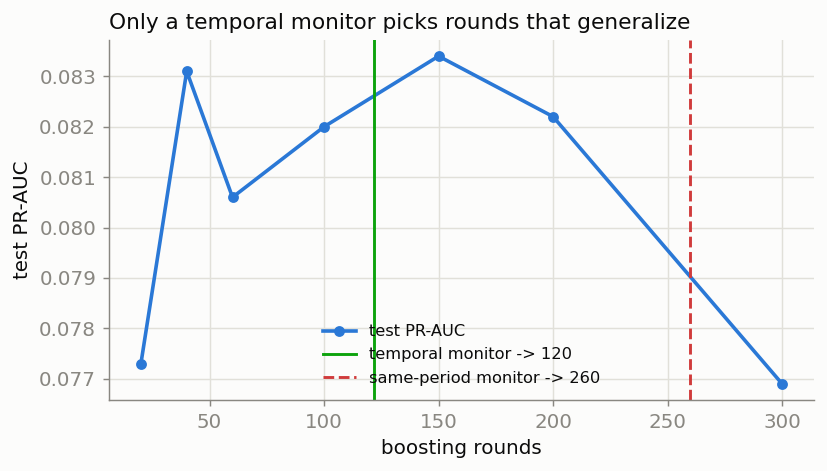

In [2]:
display(HTML(f'<img src="{R.fig_temporal_select()}">'))

### Tuned vs. Session-1 base

In [3]:
t = pd.read_csv(C.TUNING_RESULTS_CSV)
t = t[t['status']=='ok']
t['delta_vs_base'] = t['test_pr_auc']-t['base_pr_auc']
t[['model','test_pr_auc','base_pr_auc','delta_vs_base','purged_cv_ap','final_n_rounds','best_params']]

,model,test_pr_auc,base_pr_auc,delta_vs_base,purged_cv_ap,final_n_rounds,best_params
0,LightGBM,0.0782,0.0793,-0.0011,0.1223,92,"{""num_leaves"": 63, ""learning_rate"": 0.05, ""min..."
1,CatBoost,0.0860,0.0795,0.0066,0.1121,18,"{""depth"": 8, ""learning_rate"": 0.1}"
2,HistGradientBoostingClassifier,0.0699,0.0752,-0.0053,0.1165,50,"{""max_leaf_nodes"": 63, ""learning_rate"": 0.05, ..."



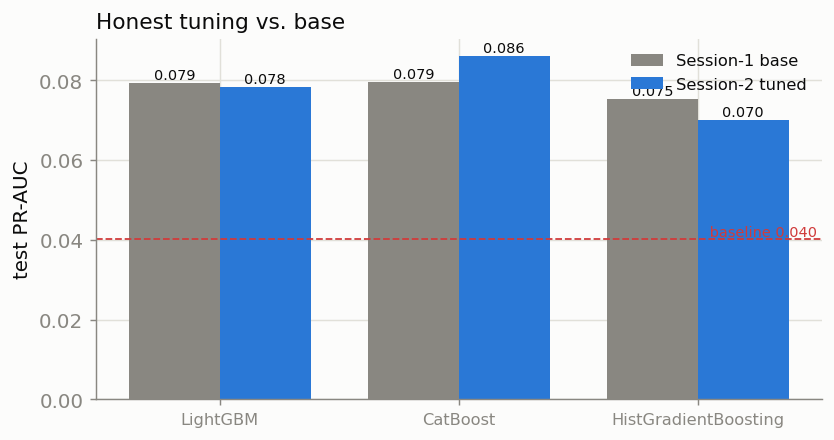

In [4]:
display(HTML(f'<img src="{R.fig_tuned_vs_base(pd.read_csv(C.TUNING_RESULTS_CSV), E.baseline())}">'))

**Takeaway.** Honest tuning **reverses the −0.018 Pass-2 regression**, landing at the base level (~0.078–0.09). It does not dramatically exceed the prior ~0.088 — as expected, that needs pipeline/feature work, deliberately deferred.